In [180]:
import wbgapi as wb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [155]:
year = 2023
target_code = 'NY.GDP.PCAP.CD'  # ВВП на душу населения ($)

# Индикаторы по категроиям
indicators = {
    # Экономика
    'FP.CPI.TOTL.ZG': 'inflation',
#     'NE.TRD.GNFS.ZS': 'trade_pct_gdp', 
    'FS.AST.PRVT.GD.ZS': 'credit_private_pct_gdp',
#     'NY.GDS.TOTL.ZS': 'gross_savings_pct_gdp',
#     'NE.CON.TOTL.ZS': 'consumption_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_net_inflows_pct_gdp',
    # Инфраструктура и технологии
    'EG.ELC.ACCS.ZS': 'electricity_access',
    'EG.USE.ELEC.KH.PC': 'electricity_consumption_pc',
    'IT.NET.USER.ZS': 'internet_users',
    'IS.ROD.PAVE.ZS': 'paved_roads_pct',
    # Здравоохранение
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SH.DYN.MORT': 'child_mortality',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',
    'SH.IMM.MEAS': 'measles_immunization',
    # Образование
    'SE.ADT.LITR.ZS': 'literacy_rate',
    'SE.SEC.ENRR': 'secondary_enrollment',
    'UIS.MYS.25PLUS': 'mean_years_schooling_25plus',
    # Демография и труд
    'SP.URB.TOTL.IN.ZS': 'urban_pop_pct',
    'SP.POP.DPND': 'dependency_ratio',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.POP.GROW': 'population_growth',
    # Экология и ресурсы
    'EN.ATM.CO2E.PC': 'co2_emissions_pc',
    'AG.LND.ARBL.ZS': 'arable_land_pct'
}


indicators_to_fetch = [target_code] + list(indicators.keys())
print(f"{len(indicators_to_fetch)} индикаторов за {year} год")

df = wb.data.DataFrame(indicators_to_fetch, time=year, index=['economy'], labels=True).reset_index()

# Переименуем столбцы к нормальному виду + удалим ненужные
df.rename(columns={target_code: 'gdp_per_capita'}, inplace=True)
for code, name in indicators.items():
    if code in df.columns:
        df.rename(columns={code: name}, inplace=True)
        
df = df.drop(['Country', 'economy'], axis = 1)

# Удаляем данные без целевой переменной
df = df.dropna(subset=['gdp_per_capita']).copy()
print(f" Стран с данными по ВВП: {df.shape[0]}")

21 индикаторов за 2023 год
 Стран с данными по ВВП: 251


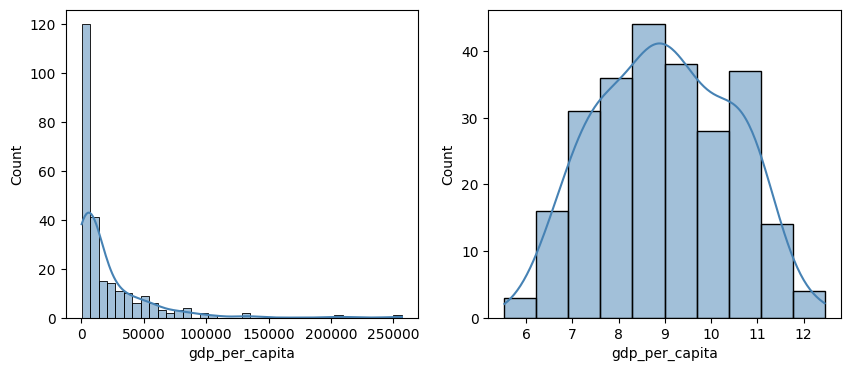

In [156]:
# Посмотрим на таргет. Можно заметить, что он сильно скошен влево, поэтому сделаем замену таргета на np.log1p(target)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(data = df['gdp_per_capita'], kde=True, ax=axes[0], color='steelblue', edgecolor='black')
sns.histplot(data = np.log1p(df['gdp_per_capita']), kde=True, ax=axes[1], color='steelblue', edgecolor='black')
plt.show()


 Пропуски по всем индикаторам:
                            missing_count  missing_pct
literacy_rate                         180        71.71
inflation                              74        29.48
credit_private_pct_gdp                 71        28.29
electricity_consumption_pc             66        26.29
secondary_enrollment                   63        25.10
arable_land_pct                        57        22.71
internet_users                         38        15.14
unemployment_rate                      27        10.76
measles_immunization                   16         6.37
health_expenditure_pct_gdp             16         6.37
child_mortality                        14         5.58
fdi_net_inflows_pct_gdp                 8         3.19
electricity_access                      1         0.40
life_expectancy                         0         0.00
dependency_ratio                        0         0.00
population_growth                       0         0.00
urban_pop_pct                    

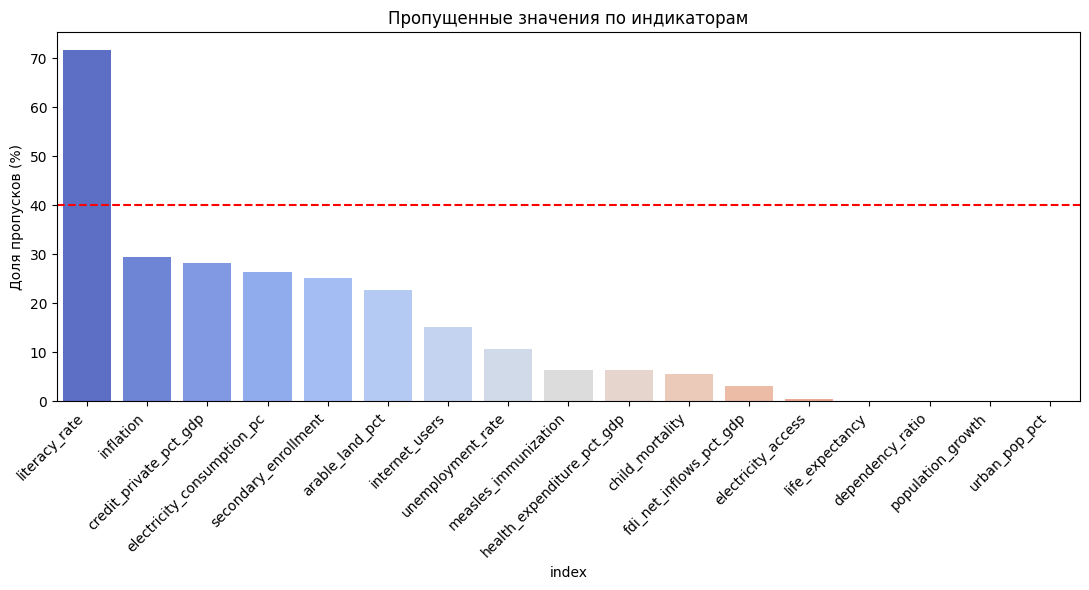

In [157]:
# Анализ пропусков по всем индикаторам
feature_cols = [col for col in df.columns if col not in ['gdp_per_capita']]

missing_stats = pd.DataFrame({
    'missing_count': df[feature_cols].isna().sum(),
    'missing_pct': (df[feature_cols].isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

print("\n Пропуски по всем индикаторам:")
print(missing_stats)

# Визуализация
plt.figure(figsize=(11, 6))
sns.barplot(
    data=missing_stats.reset_index(),
    x='index', y='missing_pct',
    hue='index', legend=False, palette='coolwarm'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Доля пропусков (%)')
plt.title('Пропущенные значения по индикаторам')
plt.axhline(40, color='red', linestyle='--', label='Порог 40%')
plt.tight_layout()
plt.show()

In [158]:
threshold = 30.0

valid_features = missing_stats[missing_stats['missing_pct'] <= threshold].index.tolist()
print(f'Выбрано признаков (пропуски ≤ {threshold}%): {len(valid_features)}')
print(f'Признаки:', *valid_features)

# Формируем итоговый датасет для моделирования
df_model = df[['gdp_per_capita'] + valid_features].copy()

Выбрано признаков (пропуски ≤ 30.0%): 16
Признаки: inflation credit_private_pct_gdp electricity_consumption_pc secondary_enrollment arable_land_pct internet_users unemployment_rate measles_immunization health_expenditure_pct_gdp child_mortality fdi_net_inflows_pct_gdp electricity_access life_expectancy dependency_ratio population_growth urban_pop_pct


In [169]:
from sklearn.model_selection import train_test_split

# Сплитим данные
X = df_model[valid_features]
y = np.log1p(df_model['gdp_per_capita'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

<Axes: >

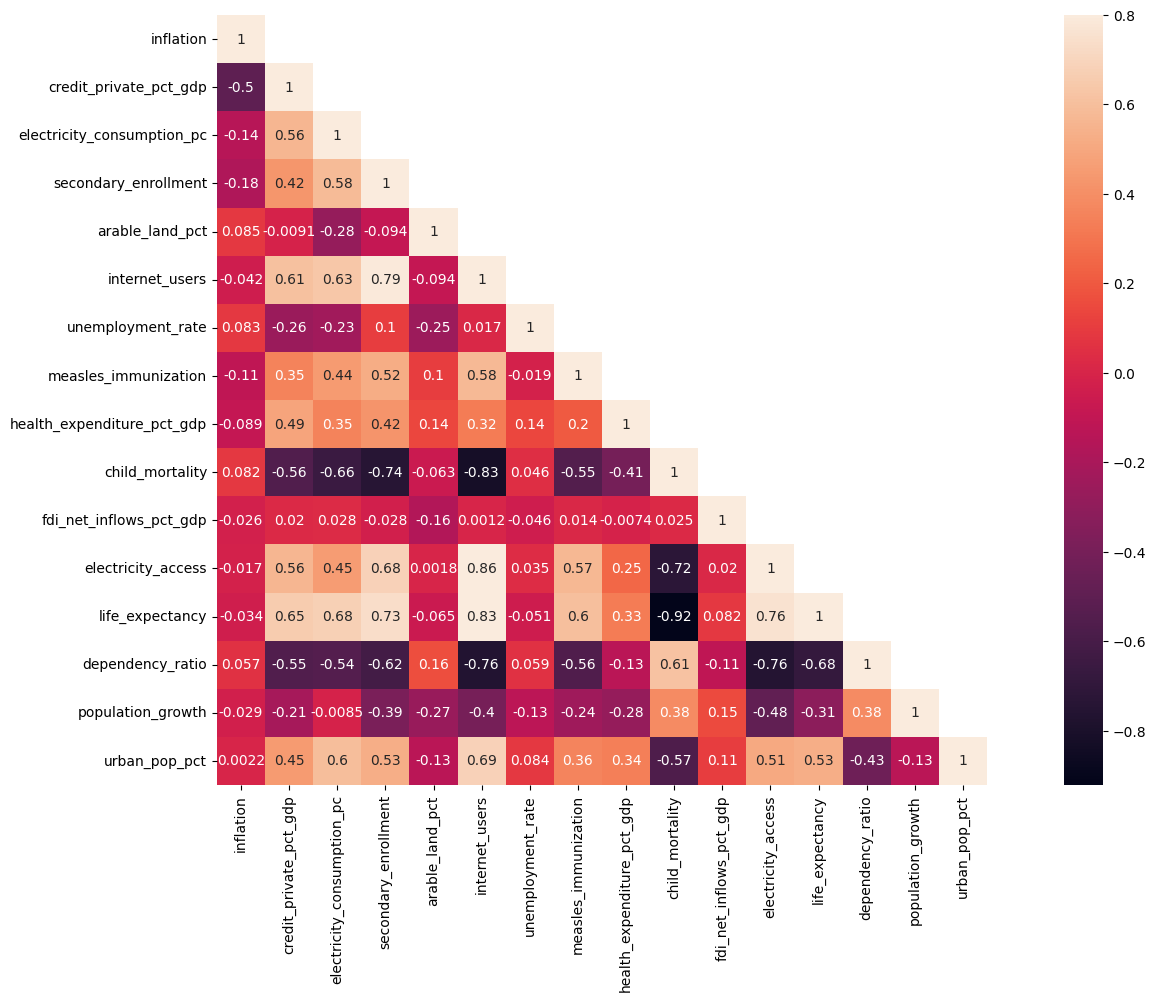

In [192]:
# Посмотрим на корреляцию между выбранными признаками
corr_matrix = X_train.corr()
mask = np.array(corr_matrix)
mask[np.tril_indices_from(mask)] = False
fig,ax= plt.subplots()
fig.set_size_inches(20,10)
sns.heatmap(corr_matrix, mask=mask,vmax=.8, square=True,annot=True)

Видим, что internet_users сильно коррелирует с несколькими другими фичами, а также |corr(child_mortality, life_expectancy)| = 0.92 ~ 1, что логично, поэтому уберем из рассмотрения и child_mortality

In [198]:
X_train = X_train.drop(['internet_users', 'child_mortality'], axis = 1)
X_test = X_test.drop(['internet_users', 'child_mortality'], axis = 1)
valid_features.remove('internet_users')
valid_features.remove('child_mortality')
valid_features

['inflation',
 'credit_private_pct_gdp',
 'electricity_consumption_pc',
 'secondary_enrollment',
 'arable_land_pct',
 'unemployment_rate',
 'measles_immunization',
 'health_expenditure_pct_gdp',
 'fdi_net_inflows_pct_gdp',
 'electricity_access',
 'life_expectancy',
 'dependency_ratio',
 'population_growth',
 'urban_pop_pct']

In [133]:
def plot_hist_and_box(df, features, log_scale=False):
    n = len(features)
    fig, axes = plt.subplots(n, 2, figsize=(5, 2 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
        
    for i, col in enumerate(features):
        data = df[col].dropna()
        
        # Опциональное логарифмирование для тяжёлых хвостов
        if log_scale and (data > 0).all():
            data = np.log1p(data)
            col_label = f'log1p({col})'
        else:
            col_label = col
            
        # Гистограмма + KDE
        sns.histplot(data, kde=True, ax=axes[i, 0], color='steelblue', edgecolor='black', bins=30)
        axes[i, 0].set_title(col_label)
        axes[i, 0].set_xlabel(col_label)
        axes[i, 0].set_ylabel('Частота')
        
        # Ящик с усами
        sns.boxplot(x=data, ax=axes[i, 1], color='lightcoral', fliersize=5)
        axes[i, 1].set_title(col_label)
        axes[i, 1].set_xlabel(col_label)
        
    plt.tight_layout()
    plt.show()

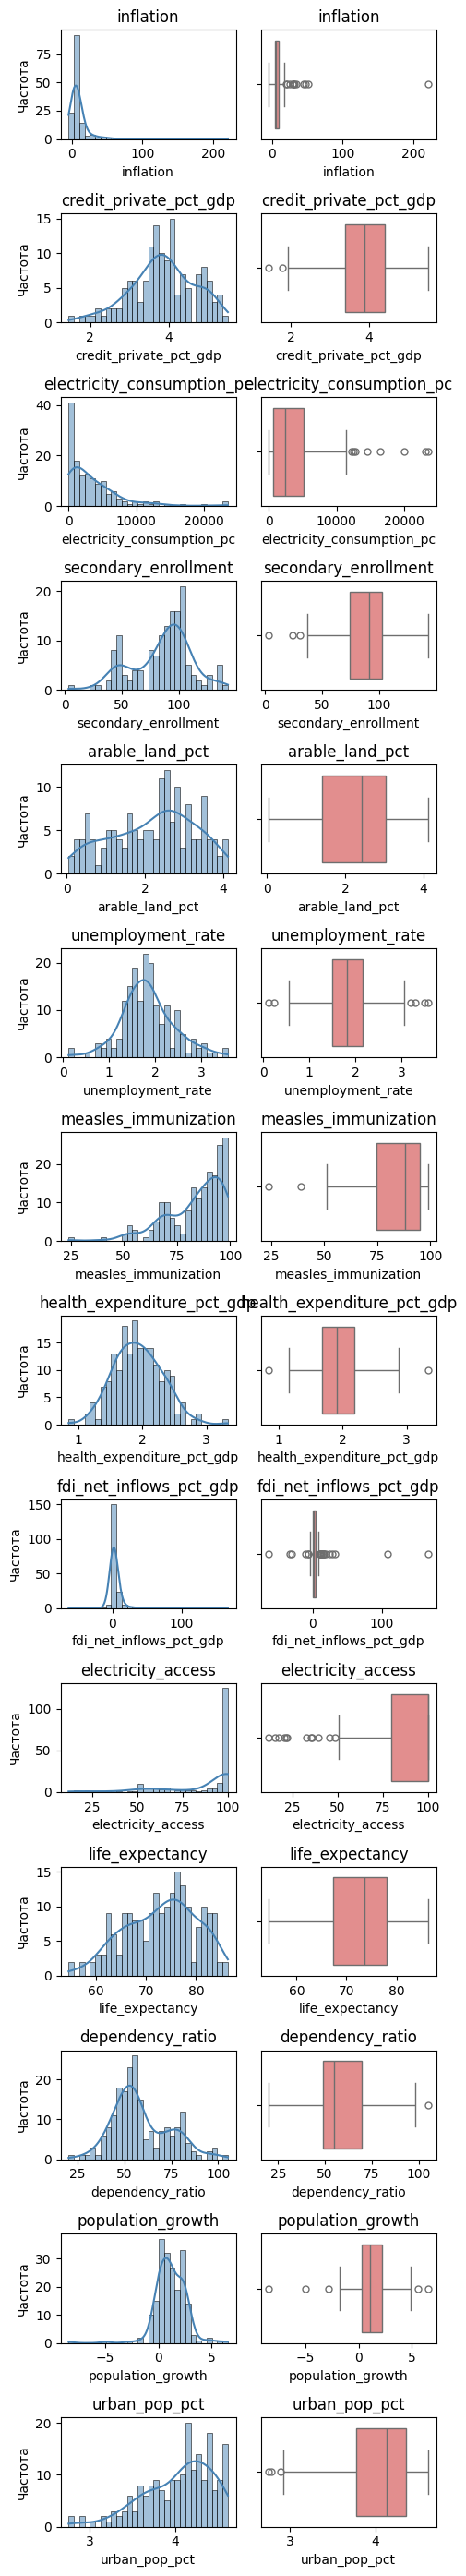

In [199]:
# Без логарифмирования
plot_hist_and_box(X_train, valid_features, log_scale=False)

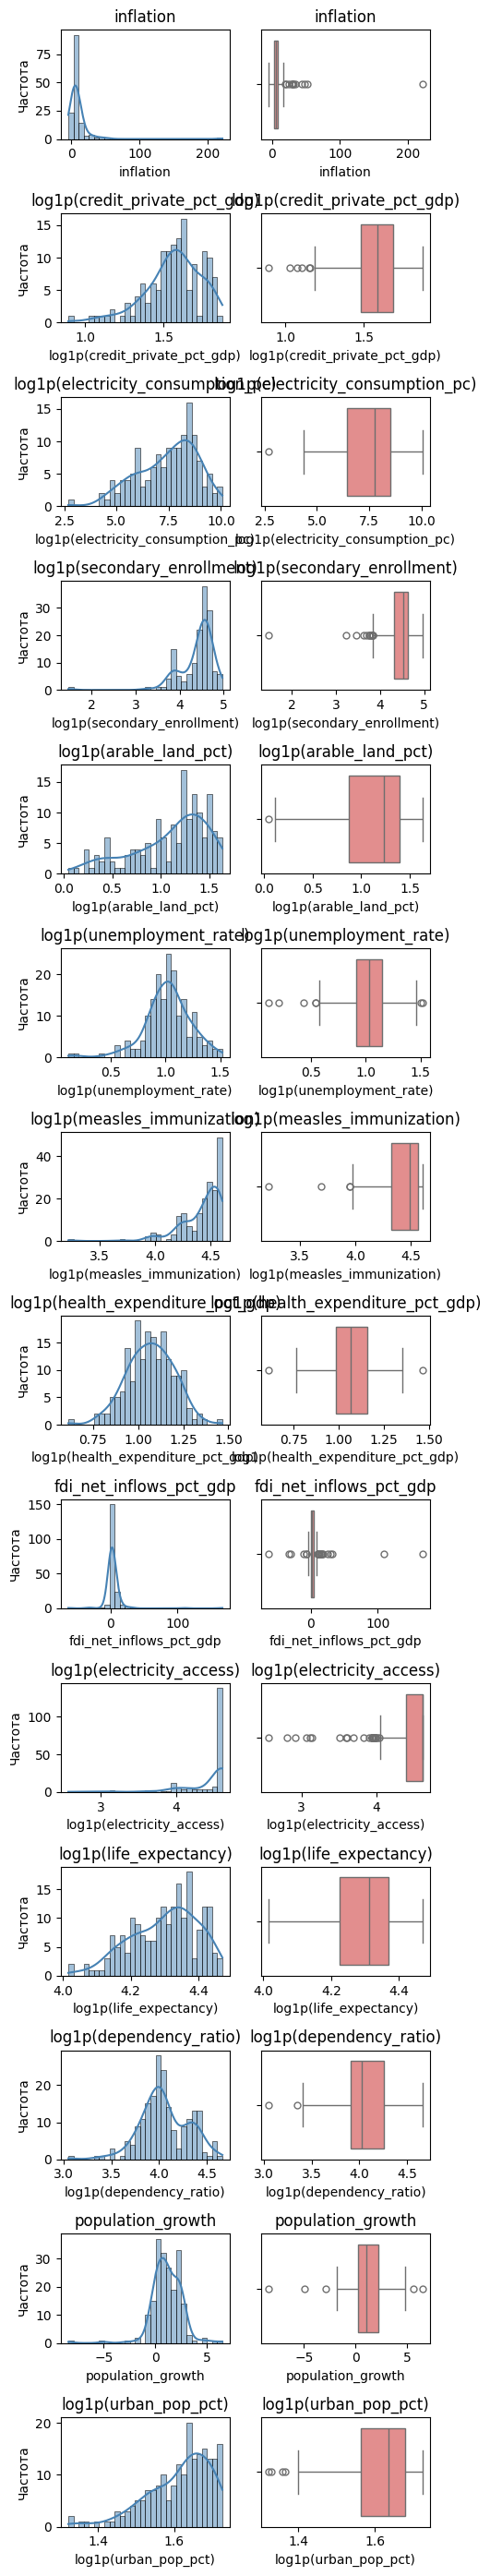

In [200]:
# С логарифмической шкалой
plot_hist_and_box(X_train, valid_features, log_scale=True)

Может показаться что выбросов очень много, но это связно с тем, что это реальные экономические данные стран, так что это их важные особенности. Вероятно, из-за этого линейная регрессия покажет не очень хороший результат. Также заменим сильно скошенные признаки на их логарифмы

In [201]:
log_features = ['credit_private_pct_gdp', 'arable_land_pct', 'unemployment_rate', 'health_expenditure_pct_gdp', 'urban_pop_pct']


for col in log_features:
    if (X_train[col].dropna() > 0).all() and (X_test[col].dropna() > 0).all():
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])
    else:
        print(f"Для {col}: есть нули или отрицательные значения")

Будем заполнять пропущенные значения, опираясь на значения ближайжих соседей, т.е ипользуем KNNImputer. Однако, если признаки будут иметь большьую разницу в масшабе, то соседи могут выбираться не оптимально из-за доминирования признаков с большой дисперсией. Поэтому для начала оценим средние и дисперсии по признакам

In [202]:
print('Средние значения признаков:\n', X_train.mean())
print('Дисперсии:\n', X_train.var())

Средние значения признаков:
 inflation                        9.468914
credit_private_pct_gdp           1.564805
electricity_consumption_pc    3651.605393
secondary_enrollment            85.463283
arable_land_pct                  1.102106
unemployment_rate                1.022504
measles_immunization            83.705582
health_expenditure_pct_gdp       1.067877
fdi_net_inflows_pct_gdp          3.902962
electricity_access              87.059177
life_expectancy                 73.016918
dependency_ratio                58.748130
population_growth                1.150126
urban_pop_pct                    1.614140
dtype: float64
Дисперсии:
 inflation                     3.971078e+02
credit_private_pct_gdp        3.267048e-02
electricity_consumption_pc    1.844556e+07
secondary_enrollment          6.600639e+02
arable_land_pct               1.496116e-01
unemployment_rate             4.435802e-02
measles_immunization          1.873975e+02
health_expenditure_pct_gdp    1.701036e-02
fdi_net_infl

Видим, что все значен я близки по масштабу, за исключением потребления электроэнергии на душу населения. Этот параметр кажется важным, поэтому сделаем модифицированный inputer: заполняем медианой все, но сохраняем маску для пропусков -> скейлим -> значения которые были пропущены изначально заполняем KNNImputer'ом

In [175]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer

class ScaledKNNImputer(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        
    def fit(self, X, y=None):
        # Маска пропусков
        self.missing_mask_ = np.isnan(X)
        # Премежуточное заполнение и скейл
        self.temp_imputer_ = SimpleImputer(strategy='median')
        X_temp = self.temp_imputer_.fit_transform(X)

        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X_temp)
        
        # Возвращаем пропуски на место + KNNImputer
        X_scaled[self.missing_mask_] = np.nan
        self.knn_imputer_ = KNNImputer(n_neighbors=self.n_neighbors, weights='distance')
        self.knn_imputer_.fit(X_scaled)
        return self
    
    def transform(self, X):
        mask = np.isnan(X)
        X_temp = self.temp_imputer_.transform(X)
        X_scaled = self.scaler_.transform(X_temp)
        X_scaled[mask] = np.nan
        return self.knn_imputer_.transform(X_scaled)

In [203]:
from sklearn.pipeline import Pipeline

# Пайплайны для рассматриваемых моделей
pipe = {
    'Ridge': Pipeline([
        ('imputer', ScaledKNNImputer()),
        ('model', Ridge(random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('imputer', ScaledKNNImputer()),
        ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),
    'CatBoost': Pipeline([
        ('imputer', ScaledKNNImputer()),
        ('model', CatBoostRegressor(random_state=42, verbose=0, thread_count=-1))
    ])
}

Также проведем подбор гиперпараметров для рассматриваемых моделей и импутера

In [204]:
param_distributions = {
    'Ridge': {
        'imputer__n_neighbors': [3, 5, 7, 9],
        'model__alpha': np.logspace(-2, 2, 15)
    },
    'RandomForest': {
        'imputer__n_neighbors': [3, 5, 7, 9],
        'model__n_estimators': [100, 200, 300, 500],
        'model__max_depth': [None, 5, 8, 12, 15],
        'model__min_samples_split': [2, 5, 10]
    },
    'CatBoost': {
        'imputer__n_neighbors': [3, 5, 7, 9],
        'model__depth': [4, 6, 8, 10],
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1]
    }
}

In [210]:
from sklearn.model_selection import RandomizedSearchCV, KFold

# Подбираем лучшие гиперпараметры для моделей с помощью RandomizedSearch
cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, pipe in pipelines.items():
    print(f"\n Тюнинг гиперпараметров для {name}")
    search = RandomizedSearchCV(
        pipe, 
        param_distributions[name], 
        n_iter=15,
        cv=cv, 
        scoring='r2', 
        n_jobs=-1,
        random_state=42,
        return_train_score=False
    )
    search.fit(X_train, y_train)
    
    best_pipe = search.best_estimator_
    y_pred_log = best_pipe.predict(X_test)
    
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)
    
    log_r2 = r2_score(y_test, y_pred_log)
    log_mae = mean_absolute_error(y_test, y_pred_log)
    
    results.append({
        'Model': name,
        'Best Params': search.best_params_,
        'CV R^2 (log)': round(search.best_score_, 4),
        'Test R^2 (log)': round(log_r2, 4),
        'Test MAE (log)': round(log_mae, 4),
        'Test MAE ($)': round(mean_absolute_error(y_test_orig, y_pred_orig), 2),
        'Test R^2 ($)': round(r2_score(y_test_orig, y_pred_orig), 4)
    })
    print(f' Тюнинг {name} завершён. Best CV R^2 (log): {search.best_score_:.4f}')


 Тюнинг гиперпараметров для Ridge
 Тюнинг Ridge завершён. Best CV R^2 (log): 0.7615

 Тюнинг гиперпараметров для RandomForest
 Тюнинг RandomForest завершён. Best CV R^2 (log): 0.8314

 Тюнинг гиперпараметров для CatBoost
 Тюнинг CatBoost завершён. Best CV R^2 (log): 0.8499


Результаты

In [214]:
results_df = pd.DataFrame(results)
print("\n Итоговое сравнение (метрики на тесте в исходной шкале - usd $):")
display(results_df)

best_model_name_R_square = results_df.loc[results_df['Test R^2 ($)'].idxmax(), 'Model']
print(f"\n Лучшая модель по R^2 (для $) на тестовой выборке: {best_model_name_R_square}")

best_model_name_MAE = results_df.loc[results_df['Test MAE ($)'].idxmin(), 'Model']
print(f"\n Лучшая модель по MAE (для $) на тестовой выборке: {best_model_name_MAE}")


 Итоговое сравнение (метрики на тесте в исходной шкале - usd $):


,Model,Best Params,CV R^2 (log),Test R^2 (log),Test MAE (log),Test MAE ($),Test R^2 ($)
0,Ridge,"{'model__alpha': 26.826957952797247, 'imputer_...",0.7615,0.7396,0.5240,27167.96,-15.9715
1,RandomForest,"{'model__n_estimators': 300, 'model__min_sampl...",0.8314,0.8624,0.3769,8597.53,0.6348
2,CatBoost,"{'model__n_estimators': 100, 'model__learning_...",0.8499,0.8833,0.3494,7660.48,0.6233



 Лучшая модель по R^2 (для $) на тестовой выборке: RandomForest

 Лучшая модель по MAE (для $) на тестовой выборке: CatBoost
